# 반도체 공정 스케줄링 시뮬레이션 결과

## 환경 설정

In [1]:
import os
import simpy
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
plt.rcParams['font.family'] = ['Noto Sans KR', 'Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# .env 파일의 환경 변수 로드
load_dotenv(override=True)

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = os.getenv('PM_HAZARD_THRESHOLD', '0.1')
PM_ACTIVE = os.getenv('PM_ACTIVE', 'True').lower() == 'true'
DOWN_ACTIVE = os.getenv('DOWN_ACTIVE', 'True').lower() == 'true'
MACHINE_RULE = os.getenv('MACHINE_RULE', 'SPTSSU')
JOB_RULE = os.getenv('JOB_RULE', 'random')
PM_RULE = os.getenv('PM_RULE', 'THRESHOLD')
DOWN_TIME_UNIT = os.getenv('DOWN_TIME_UNIT', 'M')
print(f"BASE_DATA_PATH: {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD: {PM_HAZARD_THRESHOLD}")
print(f"PM_ACTIVE: {PM_ACTIVE}")
print(f"DOWN_ACTIVE: {DOWN_ACTIVE}")
print(f"MACHINE_RULE: {MACHINE_RULE}")
print(f"JOB_RULE: {JOB_RULE}")
print(f"PM_RULE: {PM_RULE}")
print(f"DOWN_TIME_UNIT: {DOWN_TIME_UNIT}")

BASE_DATA_PATH: data/large_data
PM_HAZARD_THRESHOLD: 0.2
PM_ACTIVE: True
DOWN_ACTIVE: True
MACHINE_RULE: SPTSSU
JOB_RULE: MIN_QTIME
PM_RULE: THRESHOLD
DOWN_TIME_UNIT: H

## 모듈 import

In [2]:
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler

## 데이터 로드

In [3]:
data_loader = DataLoader(BASE_DATA_PATH)

data = data_loader.load_all_data()

print("=" * 60)
print("데이터 개요")
print("=" * 60)
print(f"Jobs: {len(data['jobs'])} 개")
print(f"Operations: {len(data['operations'])} 개")
print(f"Machines: {len(data['machines'])} 개")
print(f"Machine Failures: {len(data['machine_failure'])} 개")
print(f"Setup Times: {len(data['setup_times'])} 개")
print(f"Operation-Machine Map: {len(data['operation_machine_map'])} 개")

데이터 개요
Jobs: 100 개
Operations: 1400 개
Machines: 30 개
Machine Failures: 30 개
Setup Times: 20 개
Operation-Machine Map: 12850 개

## 시뮬레이션 실행

In [4]:
# SimPy 환경 생성
env = simpy.Environment()

# 이벤트 로거 생성
event_logger = EventLogger(env)

# 스케줄러 생성
scheduler = Scheduler(env=env,
                      data=data,
                      event_logger=event_logger,
                      pm_hazard_threshold=float(PM_HAZARD_THRESHOLD))

In [5]:
env.run(until=scheduler.job_chk_process)
fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f"반도체 공정 간트 차트 (Simulation Time: {round(env.now, 3)})")
fig.show()

## 시뮬레이션 KPI 및 통계

### 작업별 통계

100 rows × 2 columns

1400 rows × 5 columns

Makespan: 10929.956
Total Qtime Violation: 40264.201

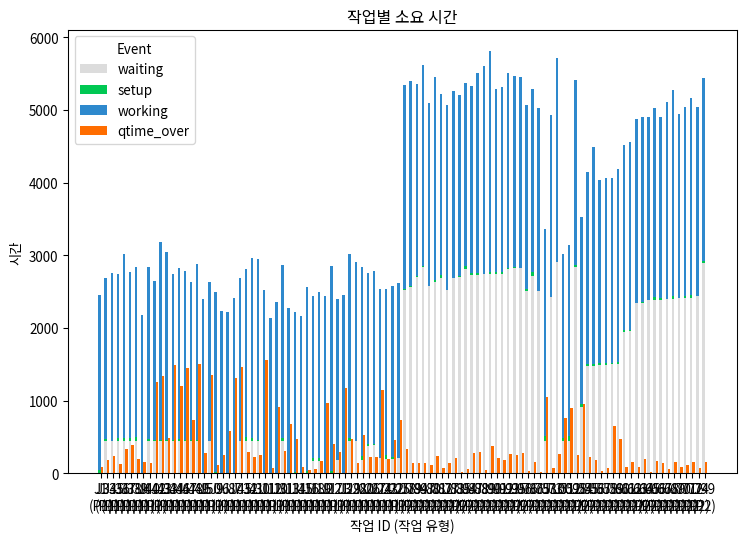

In [6]:
df_logs = pd.DataFrame(event_logger.logs)
job_info = df_logs[df_logs['resource'] == 'job']

flowtime = job_info.groupby('id').apply(lambda x: x['finish'].max() - x['start'].min())
completed = job_info.groupby('id')['finish'].max()
job_duetime_map = data['jobs'].set_index('job_id')['due_date']
tardiness = completed.to_frame(name='completed').join(job_duetime_map, on='id')
tardiness = (tardiness['completed'] - tardiness['due_date']).apply(lambda x: max(x, 0)).to_frame(name='tardiness')
process_info = flowtime.to_frame(name='flowtime').join(tardiness, on='id')
display(round(process_info, 3))

job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)
job_op_info = job_info.groupby(['id', 'op_id', 'event'], dropna=False)['duration'].sum().reset_index()
job_op_stacked = job_op_info.pivot(index=['id', 'op_id'], columns='event', values='duration').fillna(0)
job_op_stacked = job_op_stacked.reindex(columns=['waiting', 'setup', 'working', 'qtime_over'], fill_value=0)
job_type_map = data['jobs'].set_index('job_id')['job_type']
job_op_stacked = job_op_stacked.join(job_type_map, on='id')
display(job_op_stacked)
print(f"Makespan: {round(job_info['finish'].max(), 3)}")
print(f"Total Qtime Violation: {round(job_op_stacked['qtime_over'].sum(), 3)}")

job_info_sum = job_info.groupby(['id', 'event'])['duration'].sum().reset_index(['id', 'event'], drop=False)
job_stacked = job_info_sum.pivot(index='id', columns='event', values='duration').fillna(0)
job_stacked = job_stacked.reindex(columns=['waiting', 'setup', 'working', 'qtime_over'], fill_value=0)
job_stacked = job_stacked.join(job_type_map).sort_values('job_type')
job_stacked.index = [f"{i}\n({t})" for i, t in zip(job_stacked.index, job_stacked['job_type'])]
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(job_stacked))
width = 0.4

bottom = np.zeros(len(job_stacked))
for ev, color in zip(["waiting", "setup", "working"], ['#DCDCDC', '#00C853', '#2E89CD']):
    ax.bar(x - width/2, job_stacked[ev], width, label=ev, color=color, bottom=bottom)
    bottom += job_stacked[ev].values

ax.bar(x + width/2, job_stacked['qtime_over'], width, label='qtime_over', color='#FF6D00')

ax.set_xticks(x)
ax.set_xticklabels(job_stacked.index, rotation=0)
plt.title("작업별 소요 시간")
plt.xlabel("작업 ID (작업 유형)")
plt.ylabel("시간")
plt.legend(title="Event")
plt.show()

### 공정별 설비 활용률

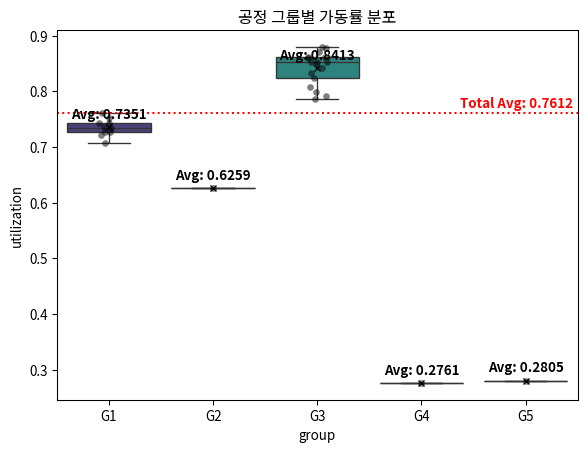

In [7]:
df_logs = pd.DataFrame(event_logger.logs)
machine_info = df_logs[df_logs['resource'] == 'machine']
machine_info['utilization'] = machine_info['finish'] - machine_info['start']
machine_utilization = pd.DataFrame(machine_info[machine_info['event'].str.startswith('working')].groupby('id')['utilization'].sum() / env.now)
machine_utilization['group'] = data['machines'].set_index('machine_id').loc[machine_utilization.index]['machine_group']
display(machine_utilization)
group_means = machine_utilization.groupby('group')['utilization'].mean()
total_mean = machine_utilization['utilization'].mean()
sns.boxplot(data=machine_utilization, x='group', y='utilization', 
            palette='viridis', showmeans=True,
            meanprops={"marker":"x", "markeredgecolor":"black", "markersize":"5"})
sns.stripplot(data=machine_utilization, x='group', y='utilization', 
              color='black', alpha=0.5, jitter=True)
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    plt.text(i, mean_val + 0.01, f'Avg: {mean_val:.4f}', 
             ha='center', va='bottom', color='black', fontweight='bold')
plt.text(len(group_means)-0.55, total_mean + 0.01, f'Total Avg: {total_mean:.4f}', color='red', fontweight='bold', ha='right')
plt.axhline(total_mean, color='red', linestyle=':')
plt.title("공정 그룹별 가동률 분포")
plt.show()